# Companion notebook for "A Statistical Framework for Robust and Reproducible BioImage Analysis"

In this notebook, you can explore the data and graphs shown in the paper titled "A Statistical Framework for Robust and Reproducible BioImage Analysis".

If you are interested in viewing the original images of Fascin knockdown (KD) HeLa cells under different experimental conditions from [Lawson et al., 2022](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9427113/), these are freely available on the [Image Data Resource](https://idr.openmicroscopy.org) under accession number IDR0139. We selected specific wells (Fig. 2-3: J05, O02, E22, L08; Fig. 4: J05, I19, G15, O02, B02, N12, L08, L18, H13, E22, H10, B06) from plate number 1093711385 for use in this work.

We took into consideration three channels for each image: cell nuclei (Hoescht), Fascin and actin. Moreover, we compared data from specific pharmacological compounds (Fig. 1-3: SN0212398523; Fig. 4: SN0212398523, SN1066932540, SN1054616339), with three controls: untreated (negative control), DMSO (vehicle control), and Leptomycin b (positive control). Image analysis was performed in CellProfiler, with a pipeline available in associated [GitHub repo](https://github.com/FrancisCrickInstitute/Enhancing-Reproducibility/).

#### Import utility functions

In [1]:
import io
import zipfile
import os
import requests

from utility_functions import *

#### Set up parameters for plots

In [2]:
plt.rcParams['font.size'] = 26
plt.rcParams['axes.linewidth'] = 2
color_dict = {'SN1066932540': 'red',
              'SN1054616339': 'yellow',
              'SN0212398523': 'orange',
              'Untreated': 'blue',
              'DMSO': 'gray',
              'Leptomycin b': 'purple'}
y_label = 'Relative Nuclear Fascin Localisation'

Download data from Zenodo and unpack

In [3]:
# Define the directory name you expect after extraction
extracted_dir = './../data_subsets'

# Check if the directory already exists
if not os.path.exists(extracted_dir):
    # Step 1: Download the zip file
    url = 'https://zenodo.org/records/15584545/files/data_subsets.zip?download=1'
    response = requests.get(url)
    zip_file = zipfile.ZipFile(io.BytesIO(response.content))

    # Step 2: Unpack the zip file
    zip_file.extractall('./../')
else:
    print(f"The directory '{extracted_dir}' already exists. Skipping download and extraction.")


The directory './../data_subsets' already exists. Skipping download and extraction.


#### Set up variables

In [4]:
plate_number = 1093711385
treatment_col = 'Treatment'
variable_of_interest = 'Fascin_Ratio'
idr_annotations_file_path = '../data_subsets/idr/idr0139-screenA-annotation.csv'
directories = ('../data_subsets/idr', '../outputs/plots', '../outputs/data')

#### Load CellProfile analysis output

In [5]:
annotations = load_and_prepare_data(idr_annotations_file_path, plate_number, 'Control Type', 'Treated')
compounds = annotations[annotations['Control Type'] == 'Treated'].set_index('Well')['Proprietary Compound'].to_dict()
treatments_to_compounds = {'Treated': 'Treated', 'Negative Control': 'Untreated',
                           'Neutral Control': 'DMSO', 'Stimulator Control': 'Leptomycin b'}
image_data = pd.read_csv('../data_subsets/cell_profiler_outputs/idr0139/Image.csv')
nuc_data = pd.read_csv('../data_subsets/cell_profiler_outputs/idr0139/Nuclei.csv')
cyto_data = pd.read_csv('../data_subsets/cell_profiler_outputs/idr0139/Cytoplasm.csv')
treatments = annotations.set_index('Well')['Control Type'].to_dict()

#### Select data subsets

In [6]:
data_subset = prepare_data(nuc_data, cyto_data, image_data, None, treatments, treatments_to_compounds, compounds,
                           ['J05', 'O02', 'E22', 'L08'], ['Fascin'])

#### Plot figures

##### Figure 2A

Processing:   0%|          | 0/4900 [00:00<?, ?it/s]

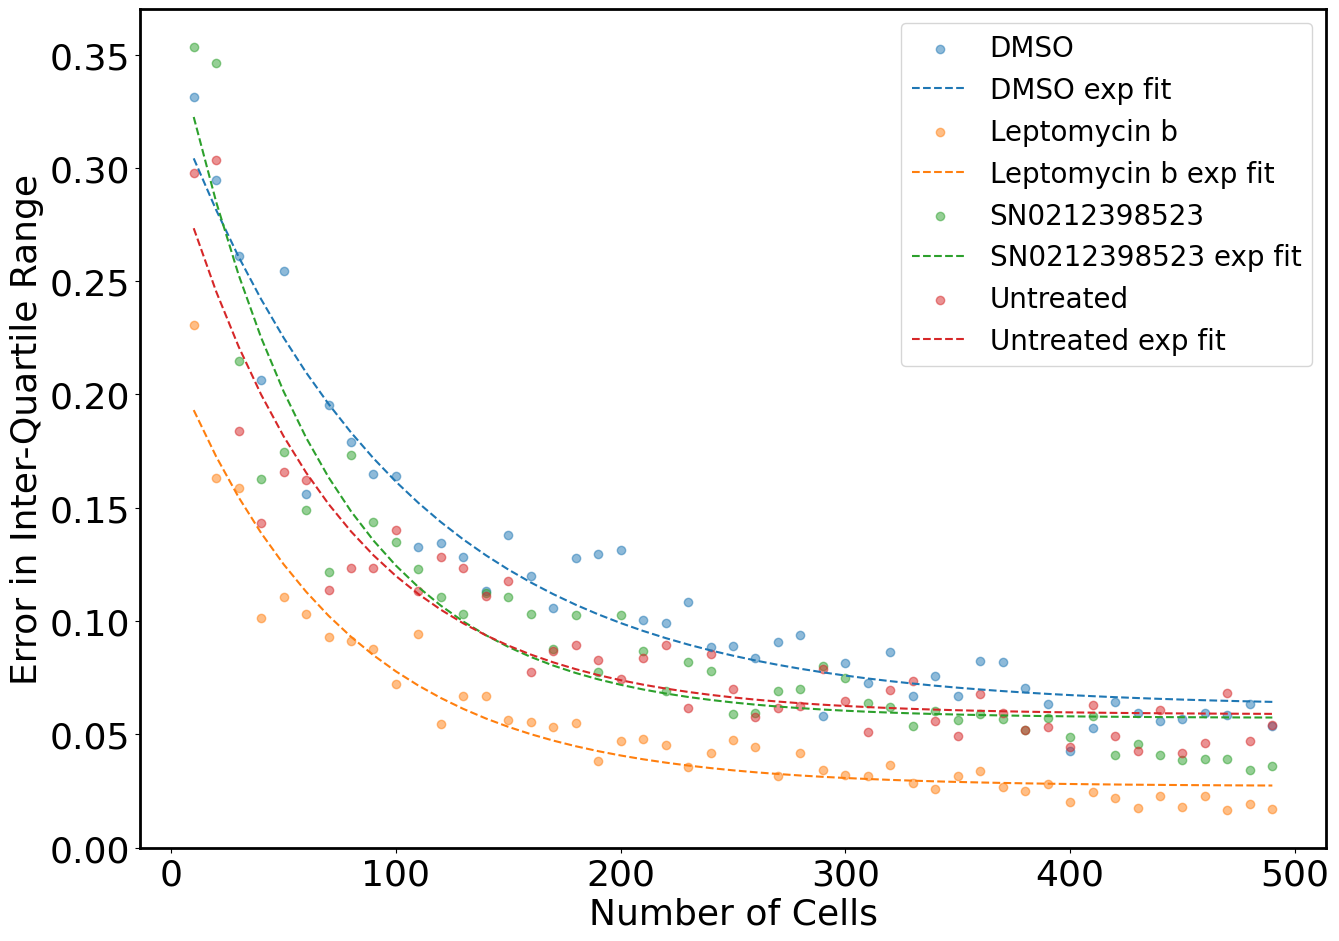

In [7]:
plot_iqr_v_sample_size([*range(10, 500, 10)], 100, data_subset, treatment_col, variable_of_interest,
                       'Error in Inter-Quartile Range')

##### Figure 2B-H

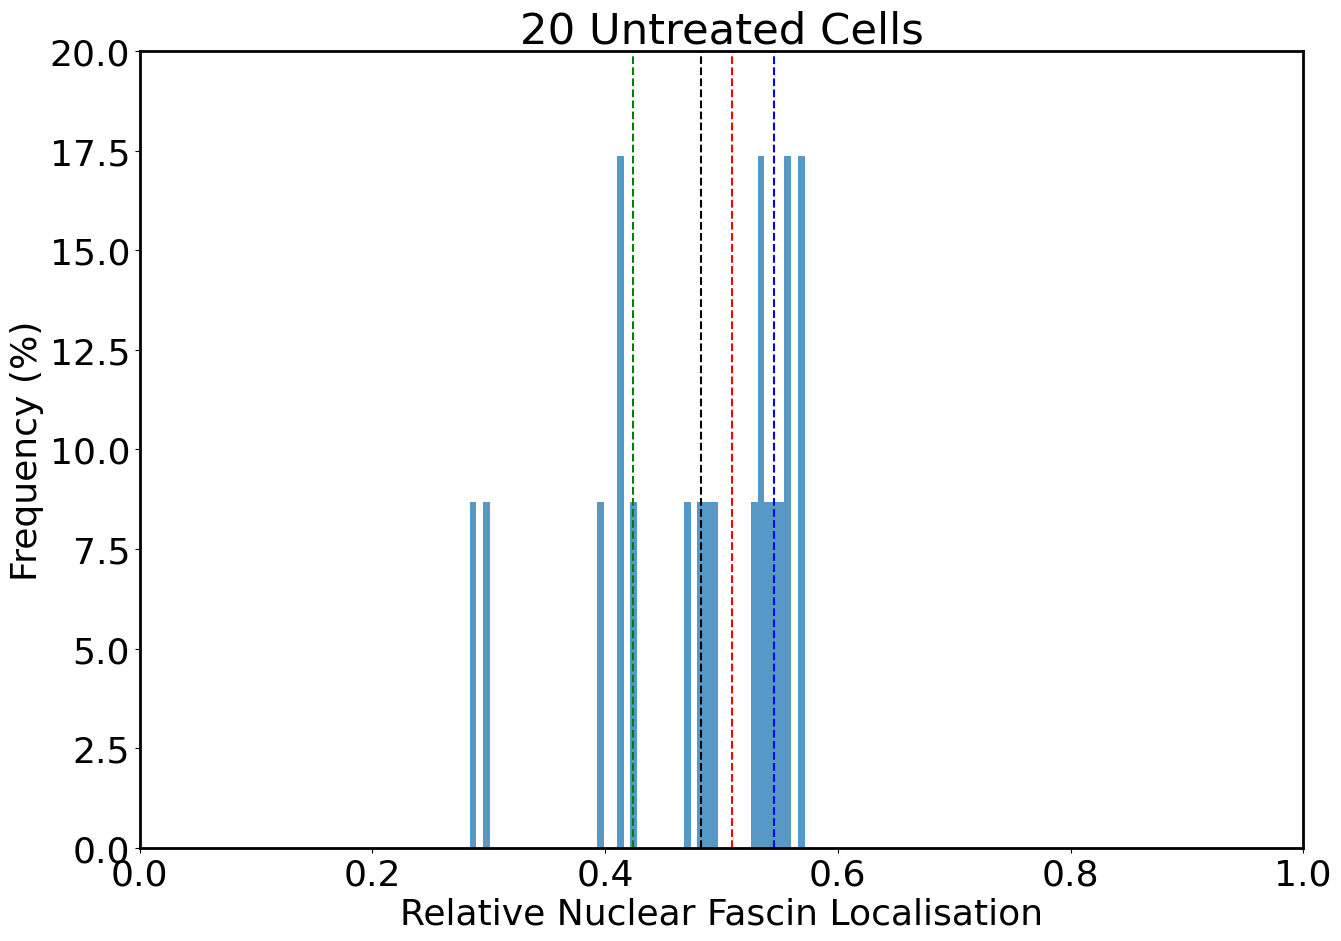

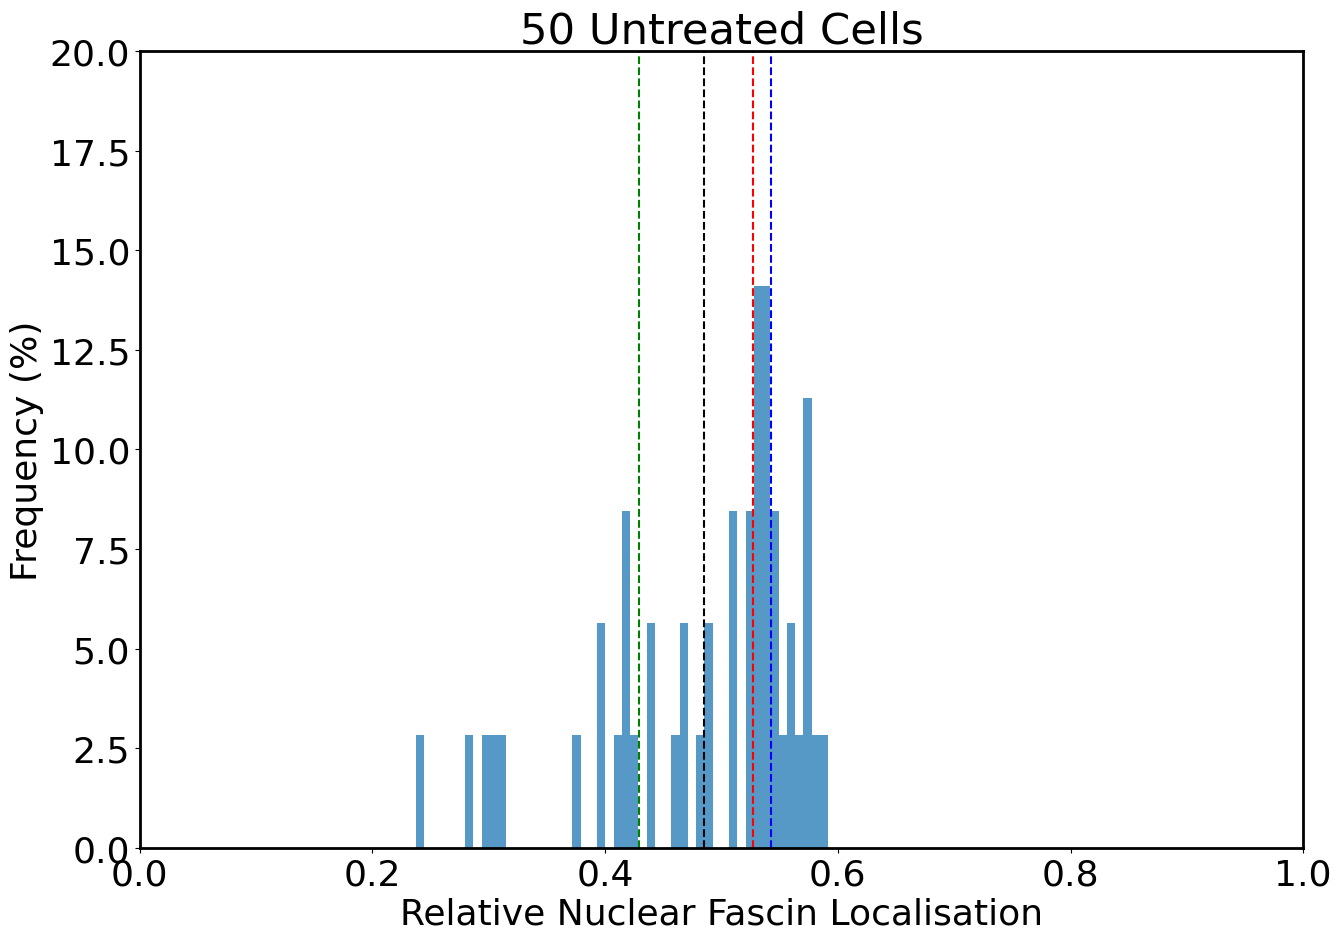

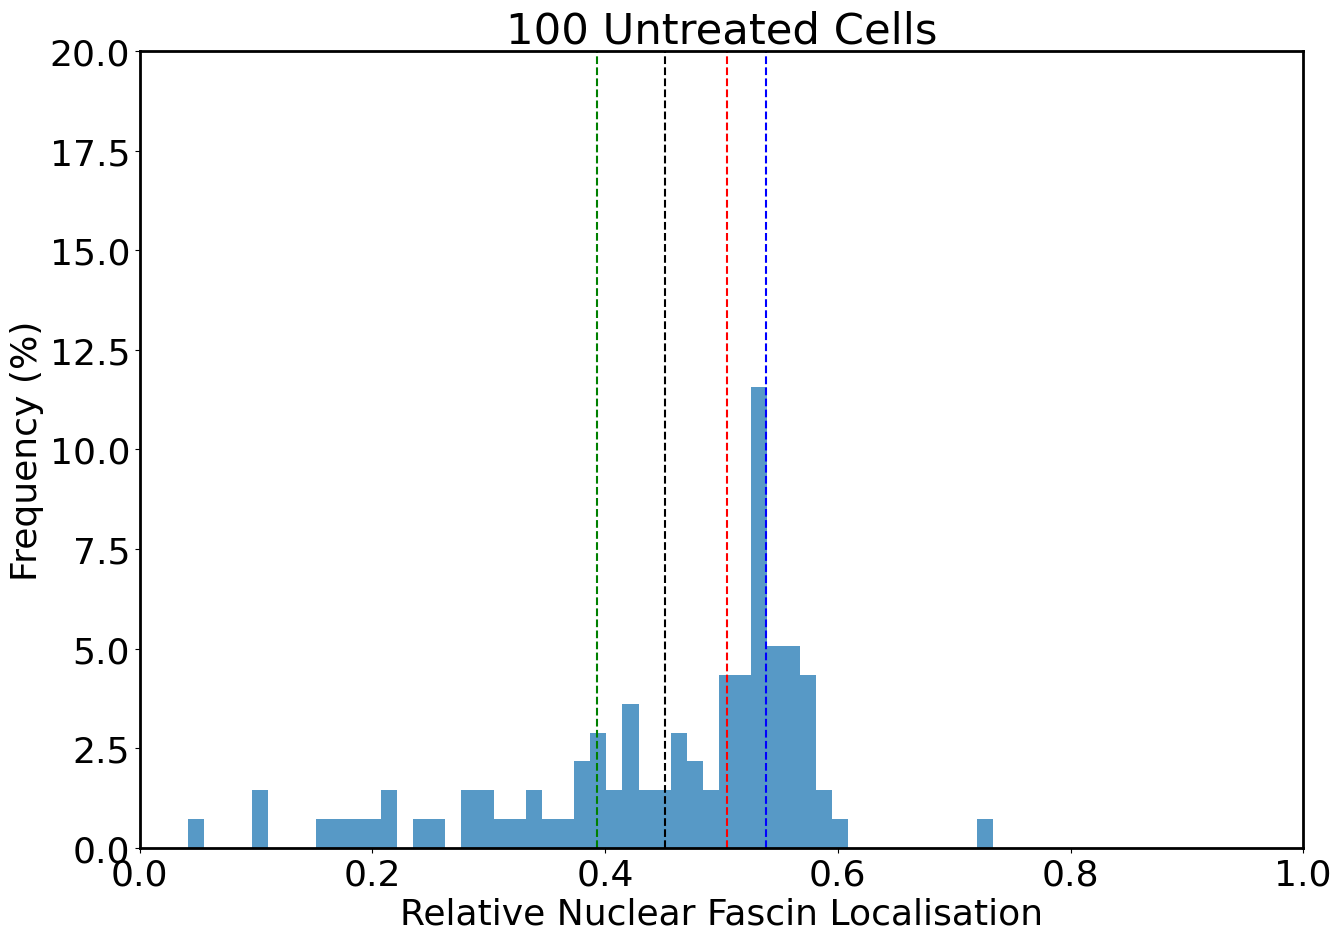

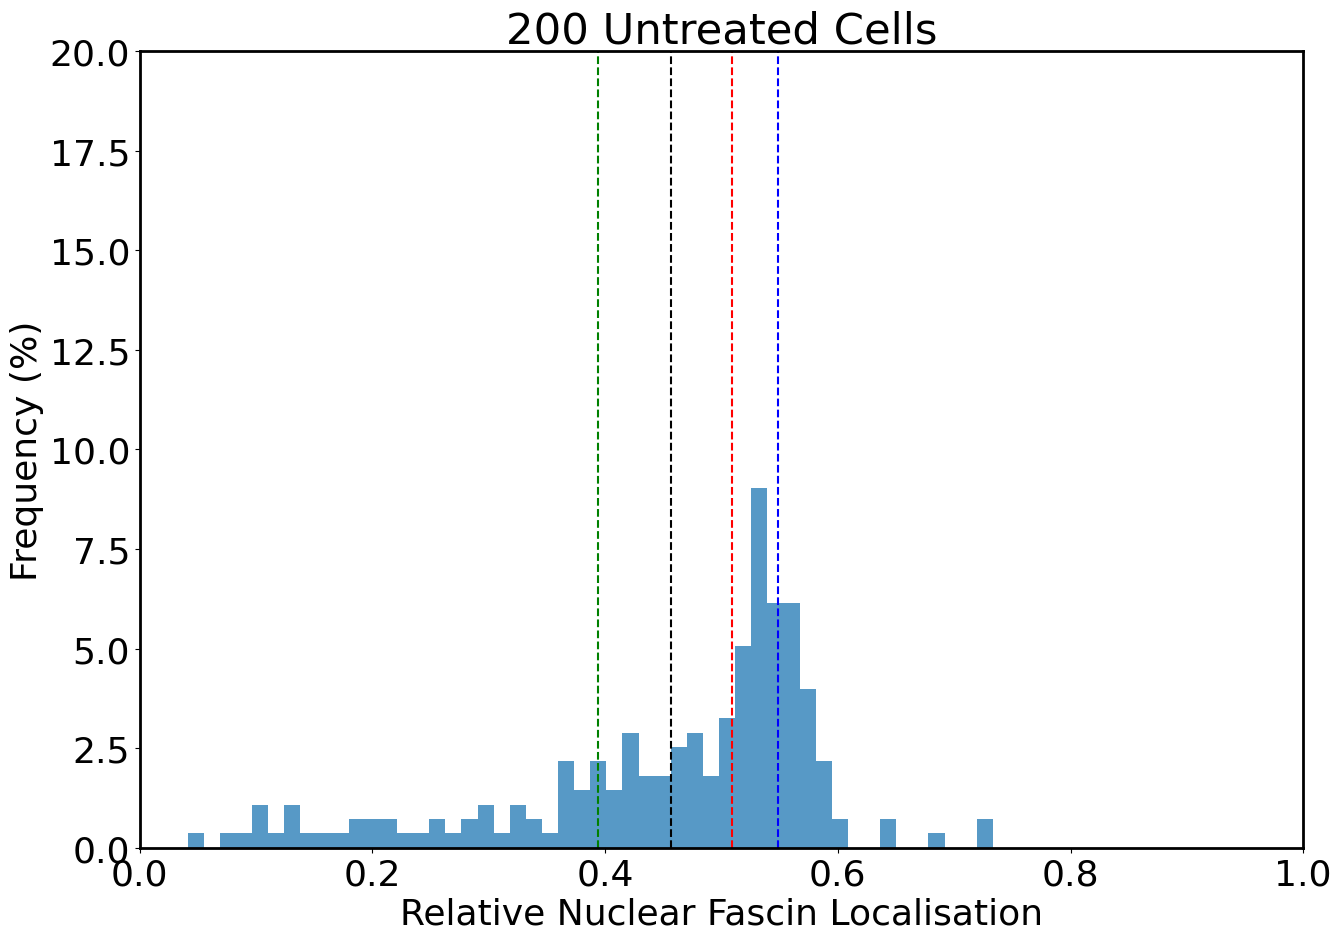

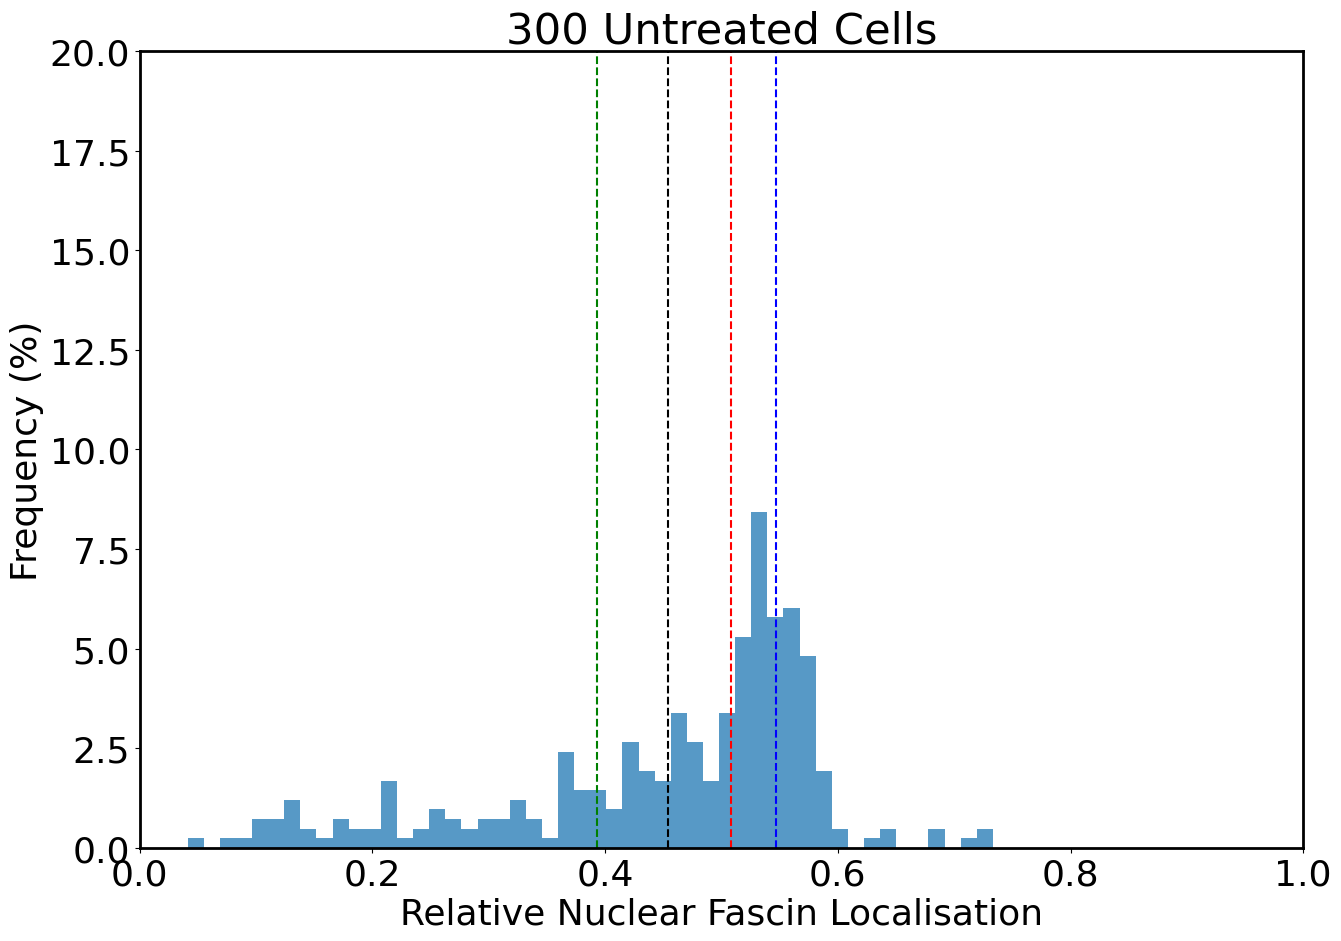

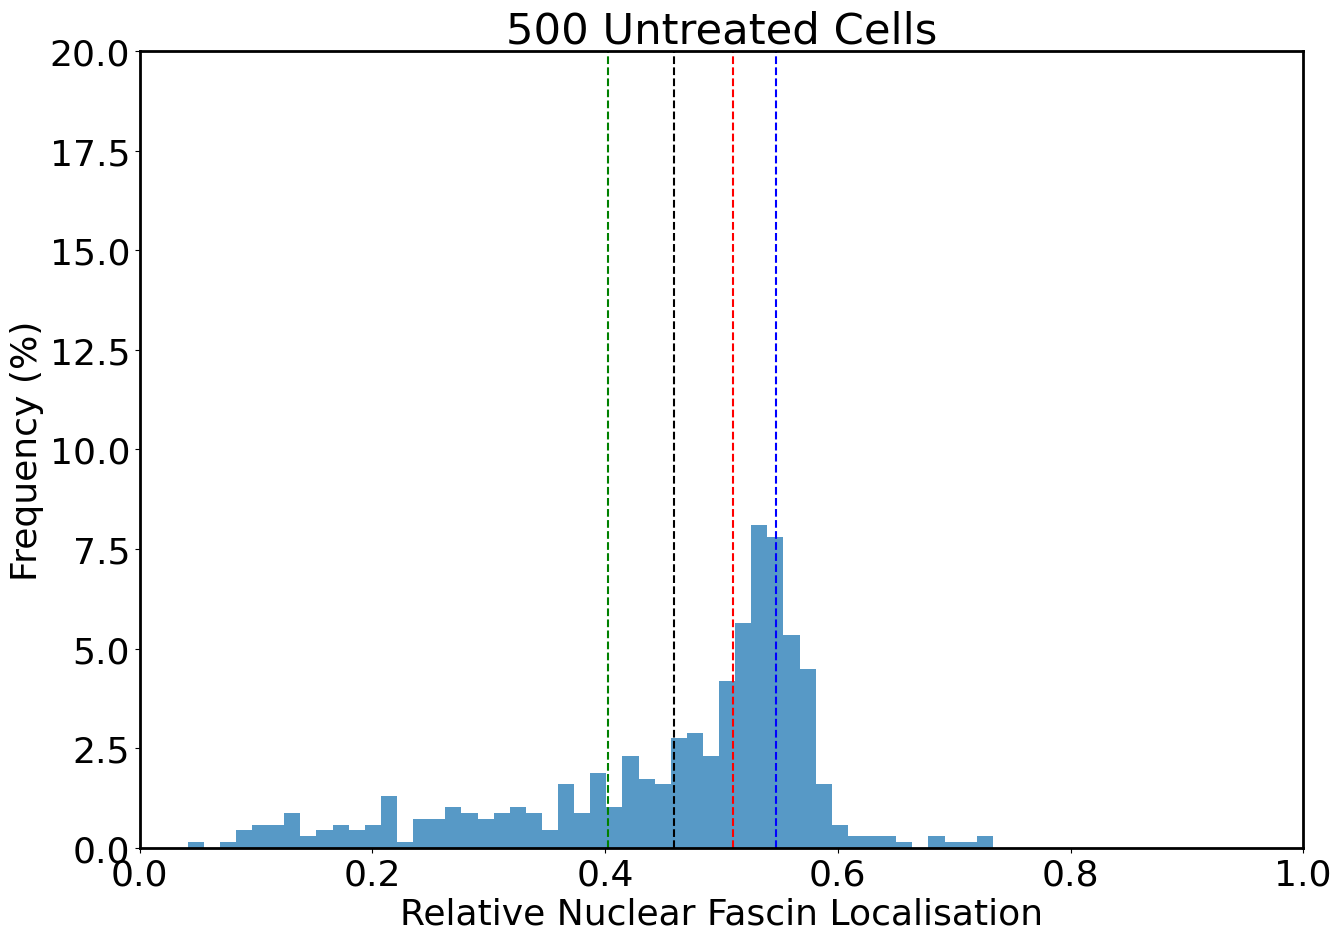

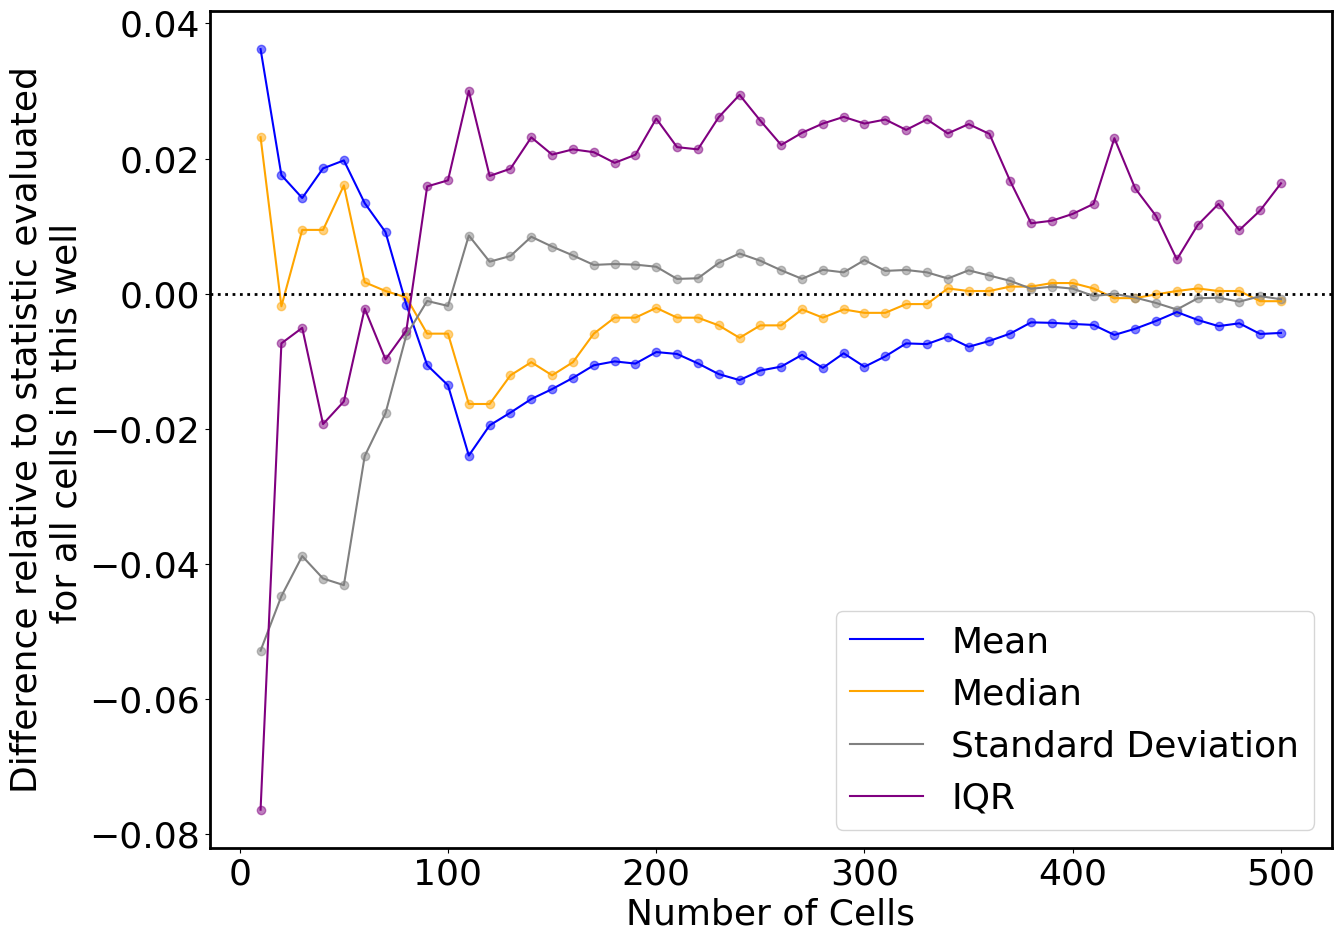

In [8]:
plot_cumulative_histogram_samples(data_subset, variable_of_interest, treatment_col, 'Untreated', y_label)

##### Figure 3A-F

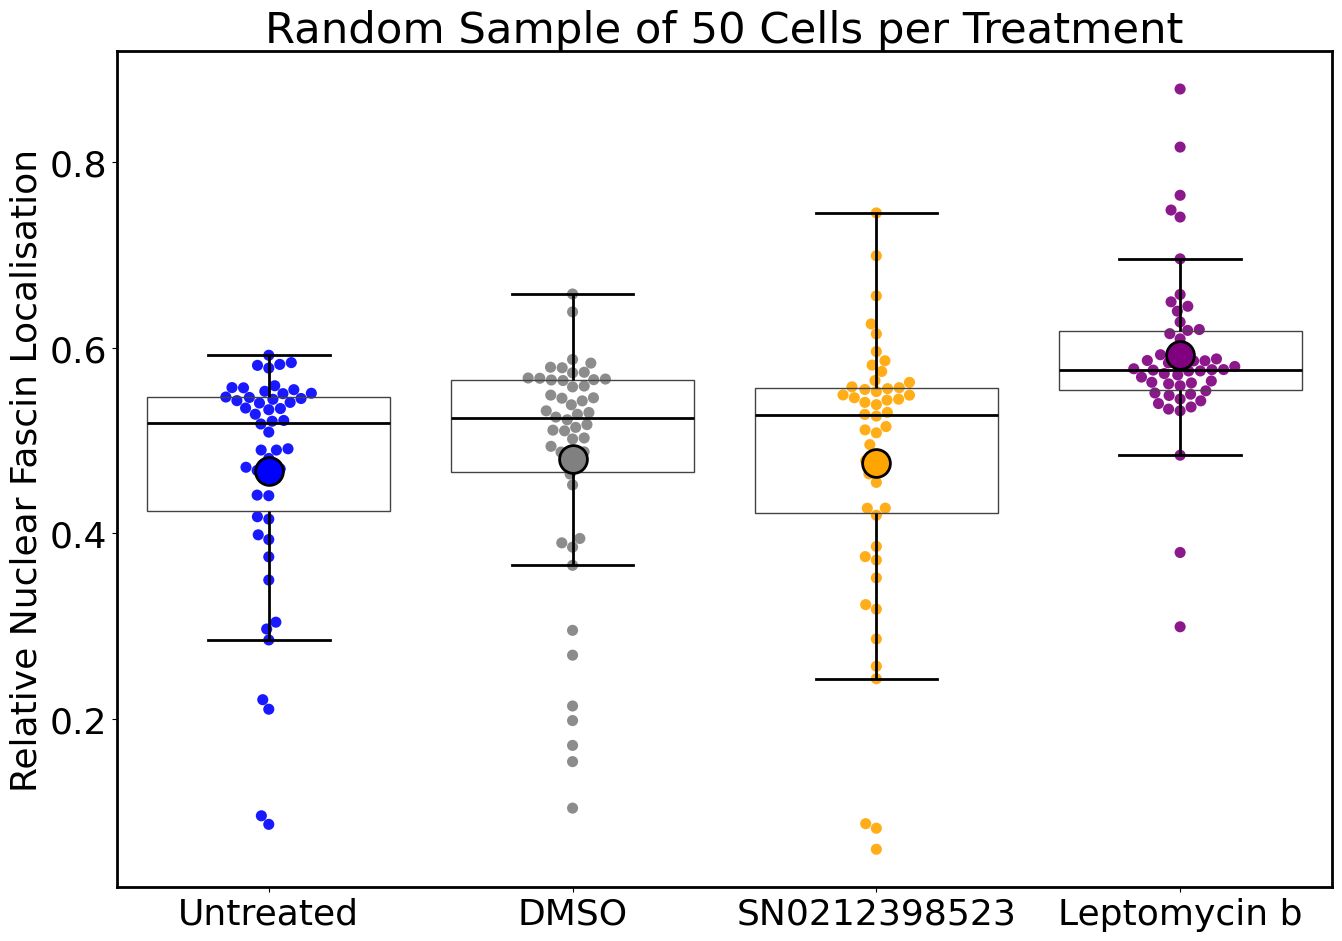

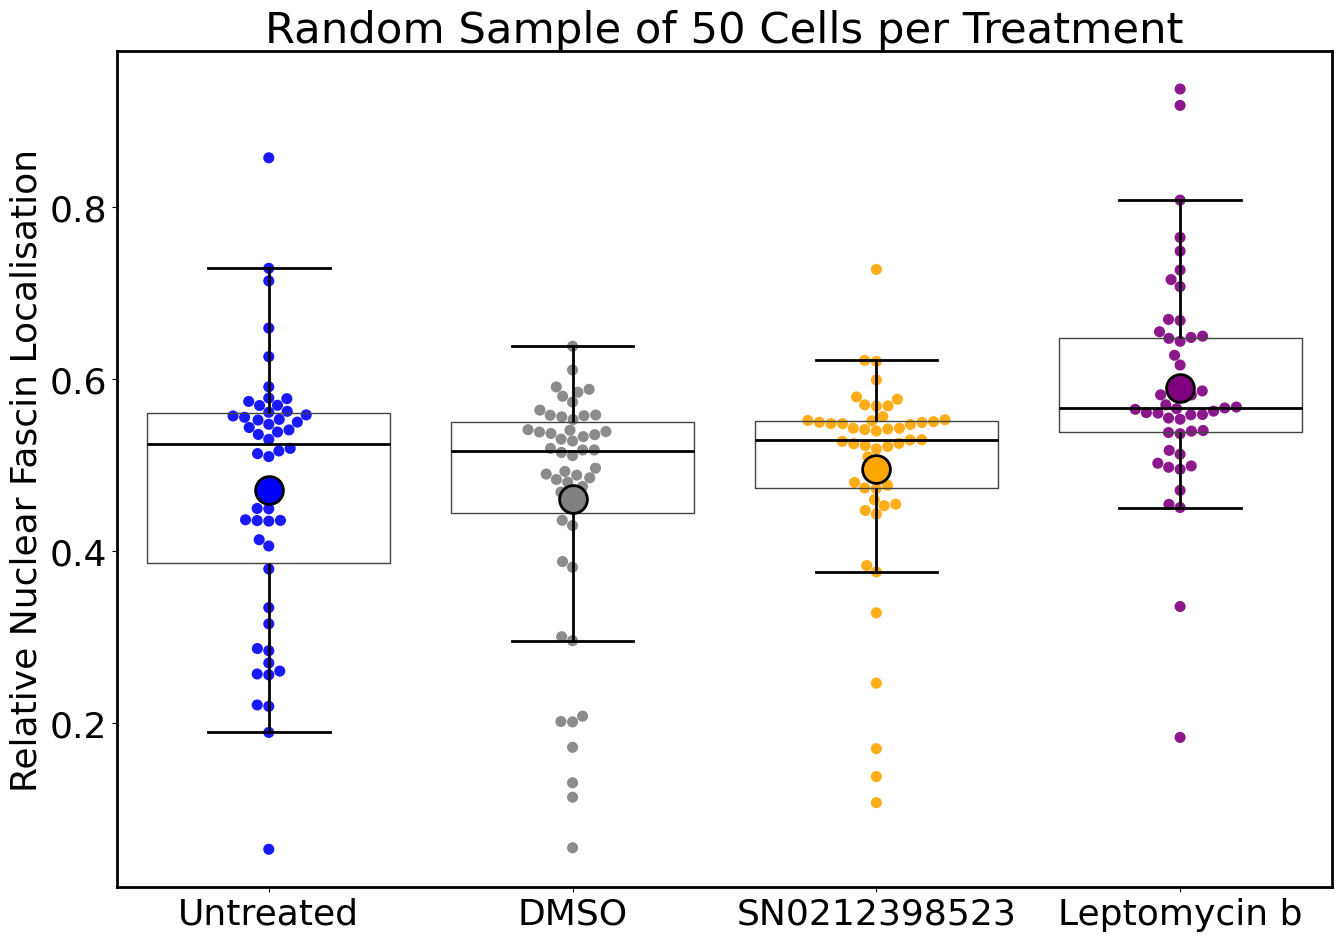

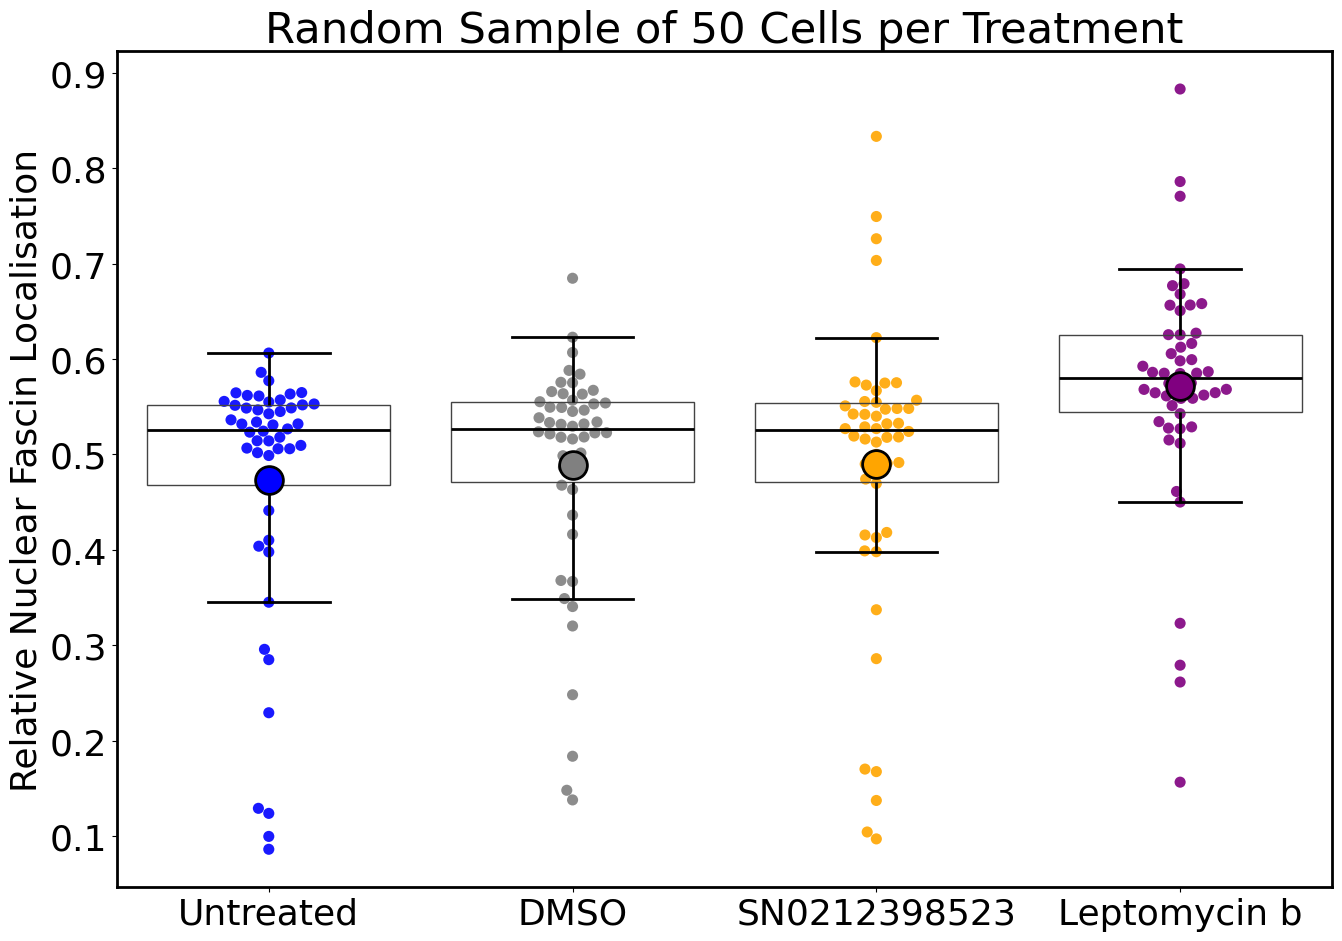

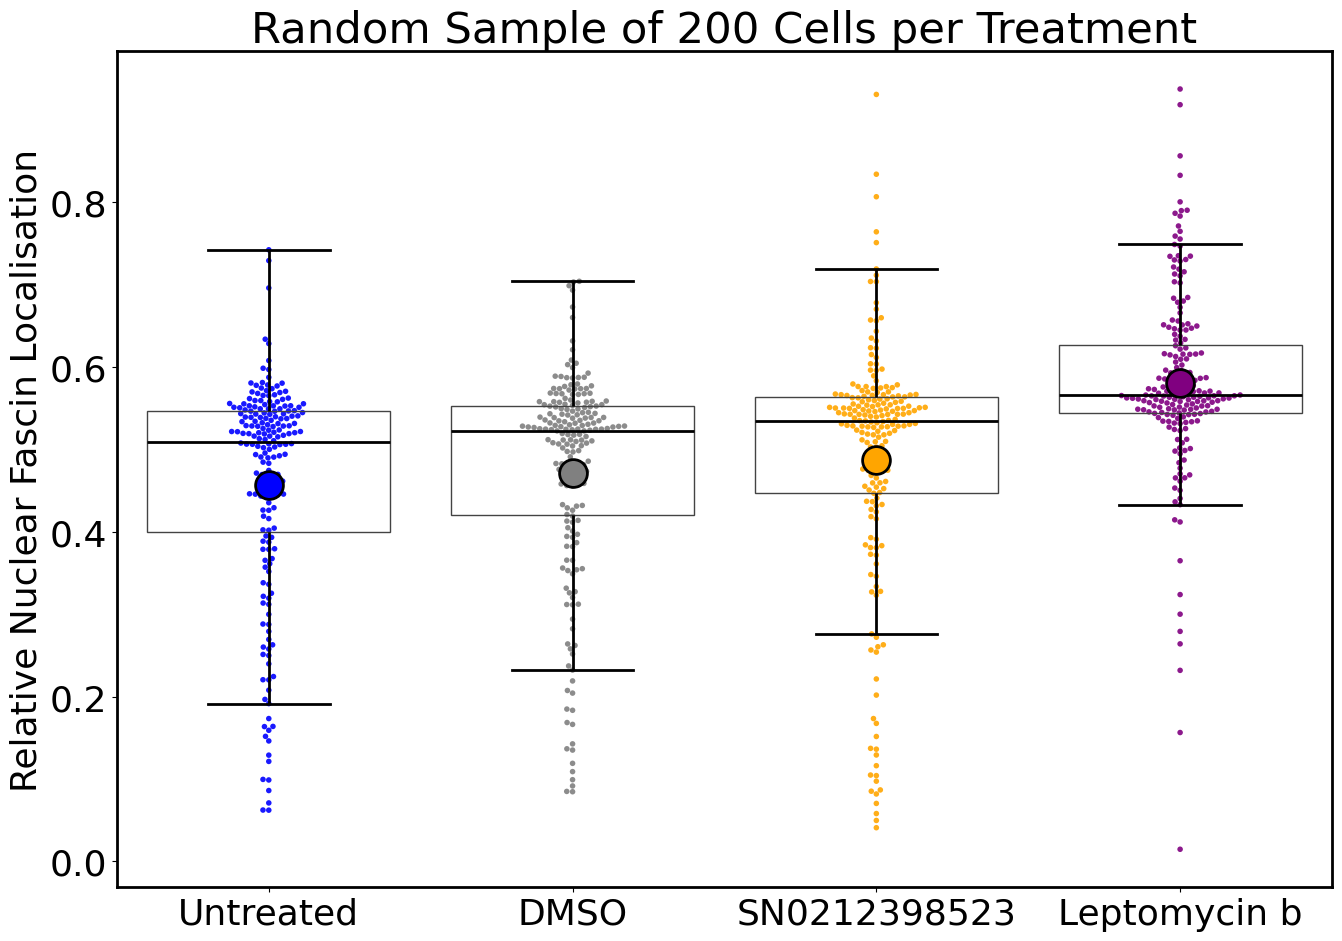

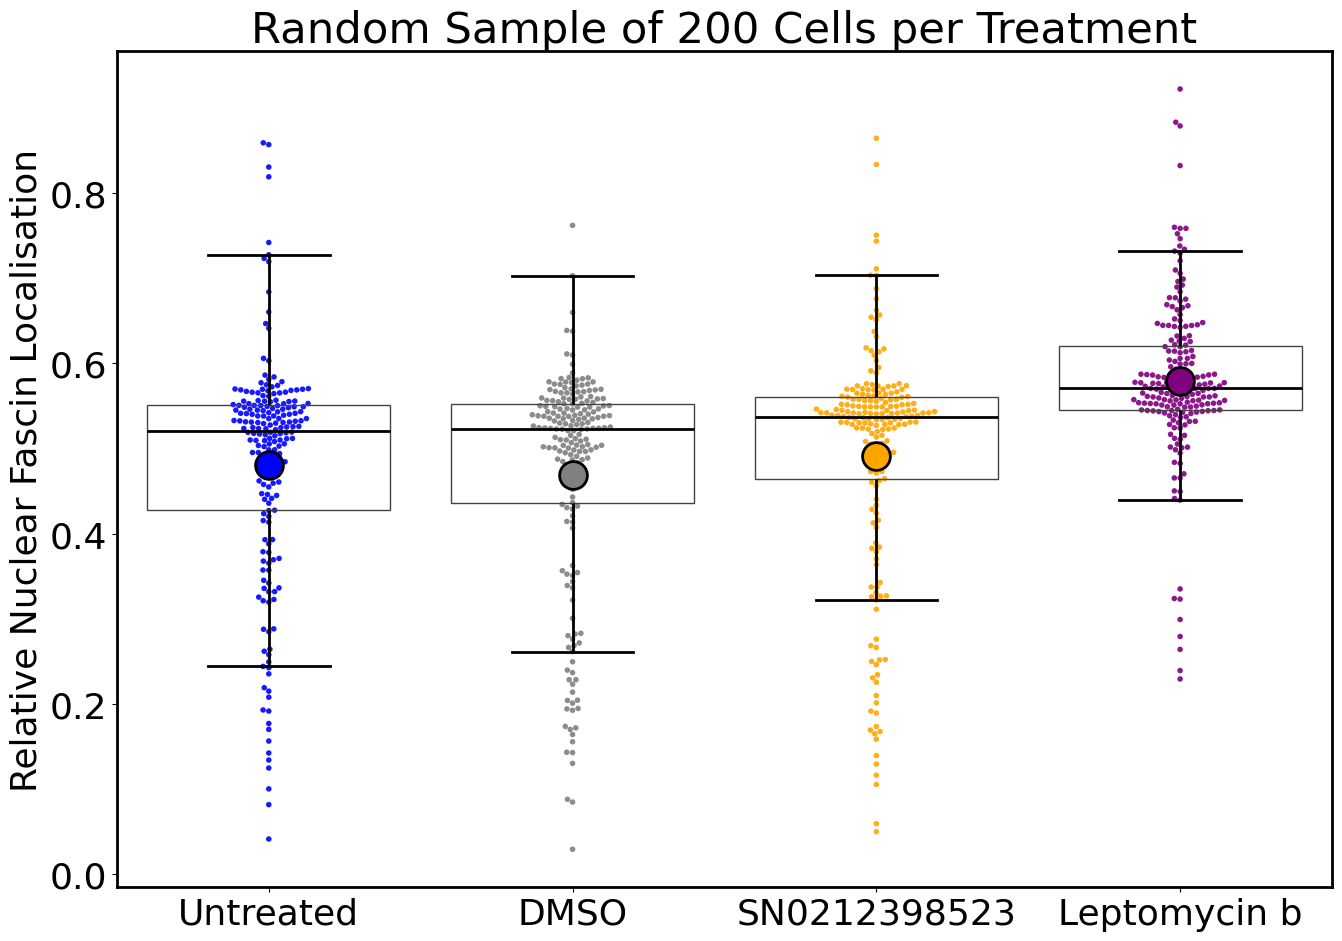

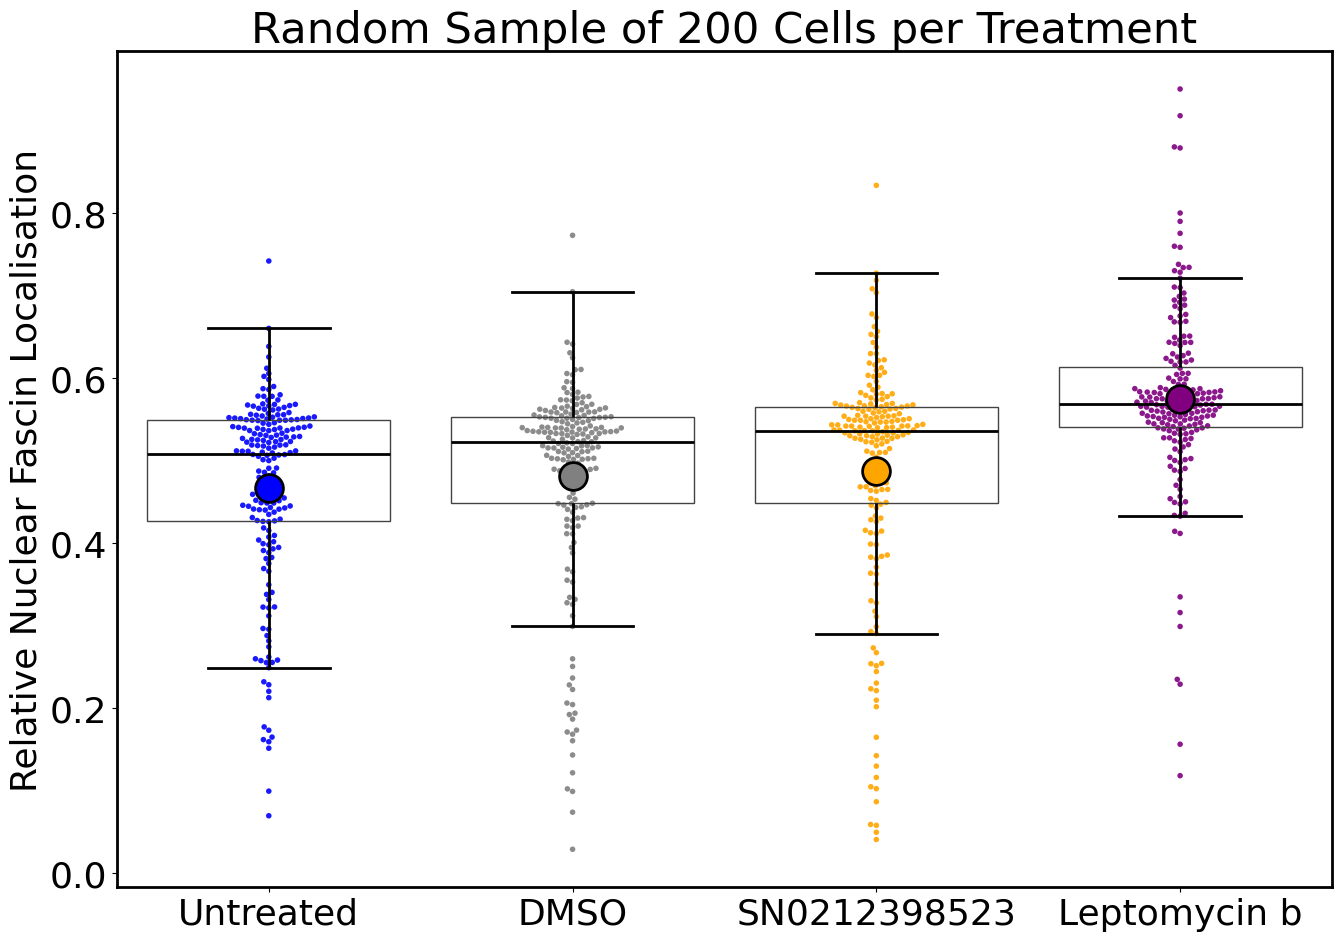

In [9]:
point_size = 8
random_seed = 42

for s in [50, 200]:
    if s > 50:
        point_size = 4
    for i in range(3):
        generate_swarmplot(['Untreated', 'DMSO', 'SN0212398523', 'Leptomycin b'], data_subset, color_dict,
                           treatment_col, variable_of_interest, y_label,
                           point_size=point_size, random_seed=random_seed, sample_size=s,
                           title=f'Random Sample of {s} Cells per Treatment')
        random_seed = random_seed + 1

##### FIGURE 3 G - I

Processing:   0%|          | 0/4900 [00:00<?, ?it/s]

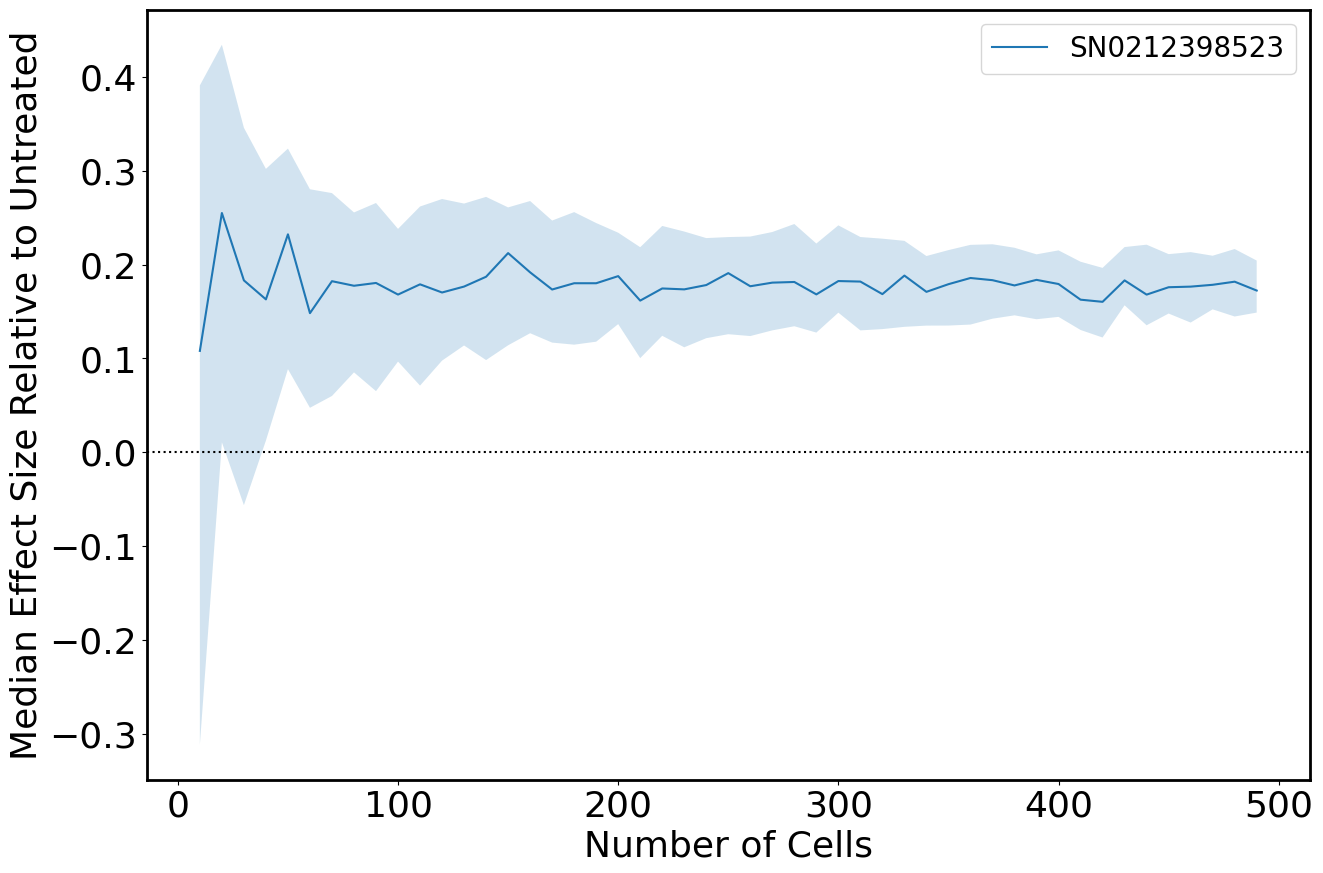

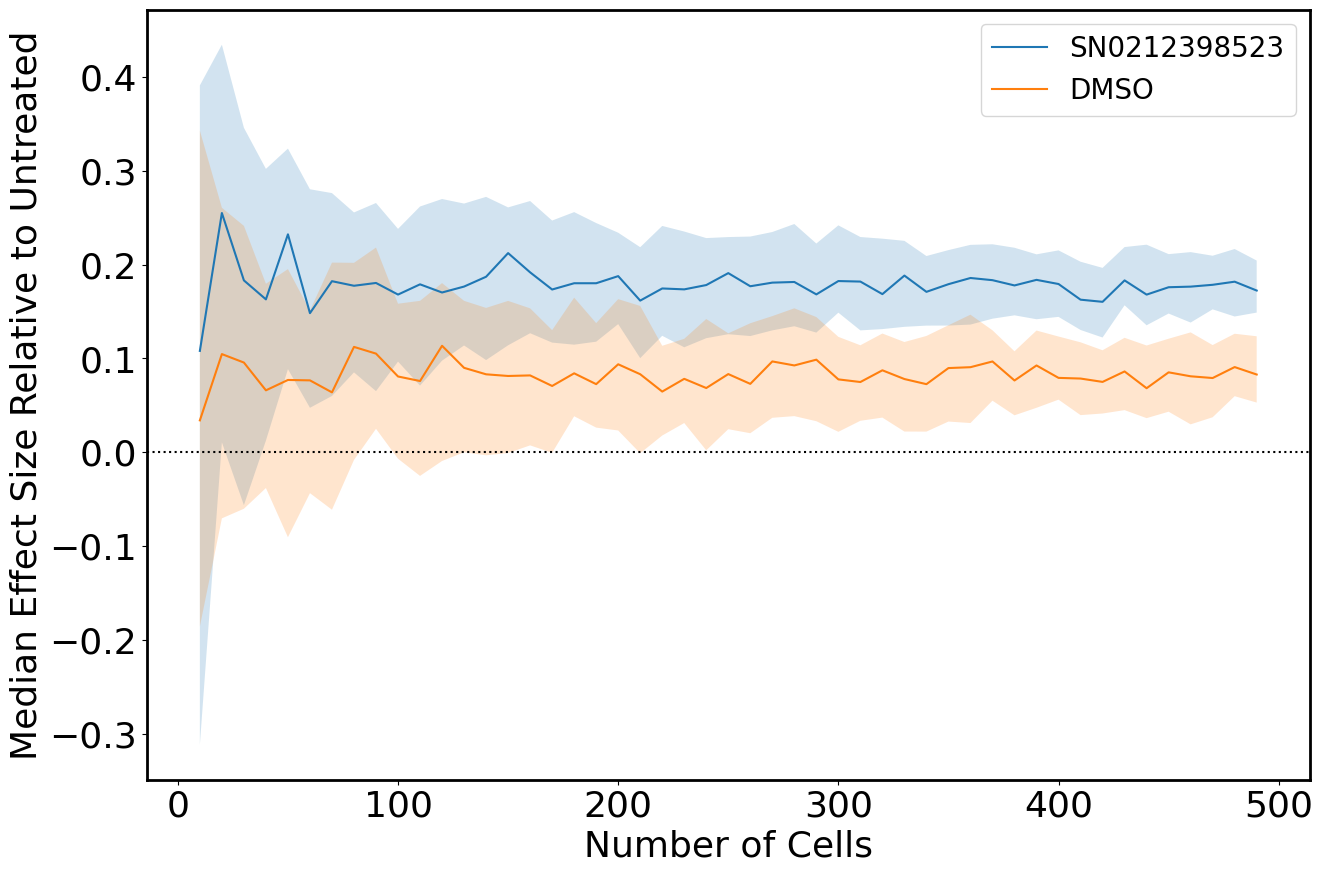

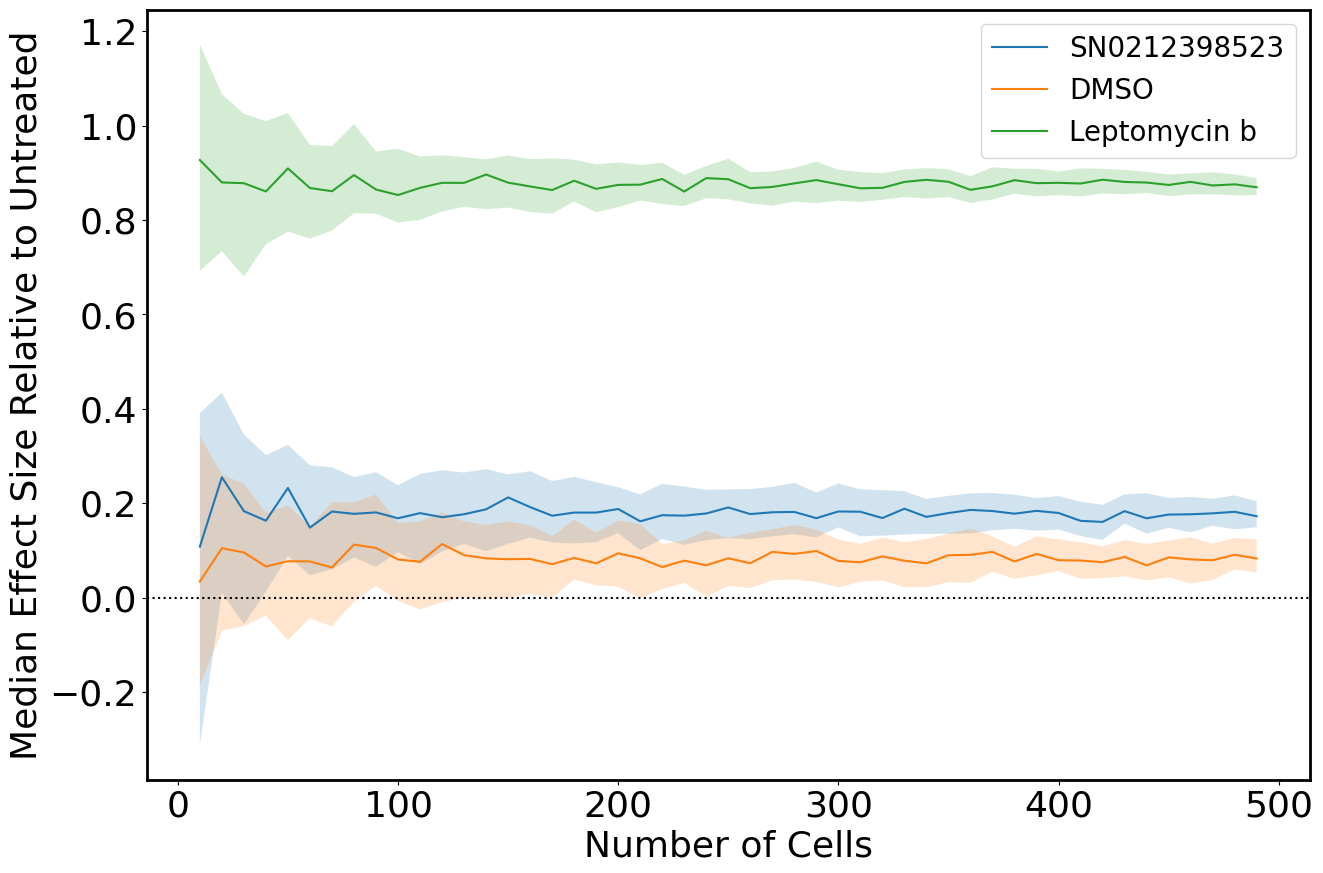

In [10]:
plot_effect_size_v_sample_size([*range(10, 500, 10)], 100, data_subset, treatment_col, variable_of_interest,
                               'Median Effect Size Relative to Untreated', ['SN0212398523', 'DMSO', 'Leptomycin b'],
                               'Untreated')

##### Supplementary Figure 1

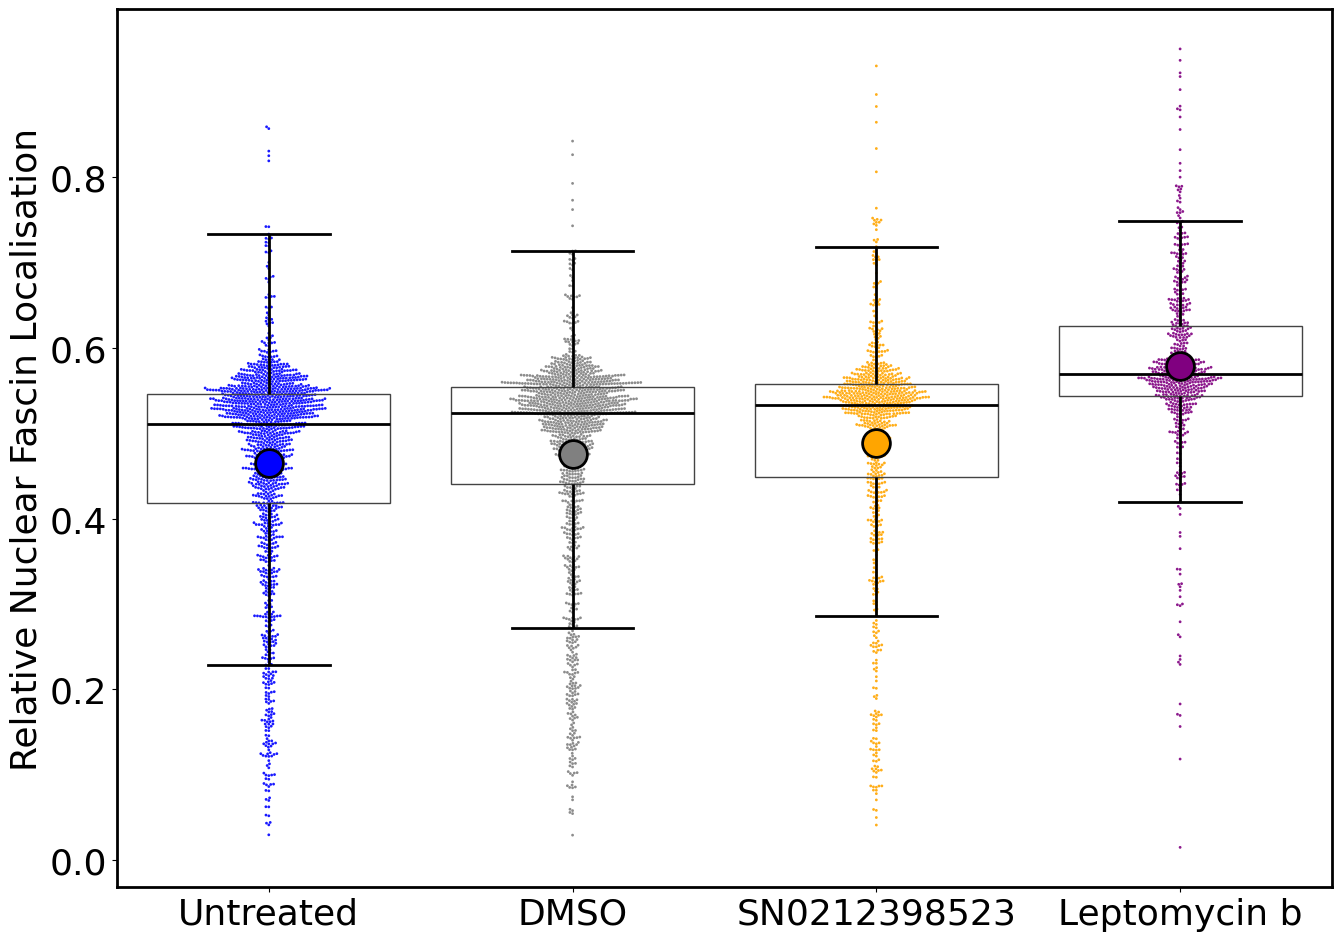

In [11]:
generate_swarmplot(['Untreated', 'DMSO', 'SN0212398523', 'Leptomycin b'], data_subset, color_dict, treatment_col,
                   variable_of_interest, y_label)

##### Supplementary Figure 2A-C

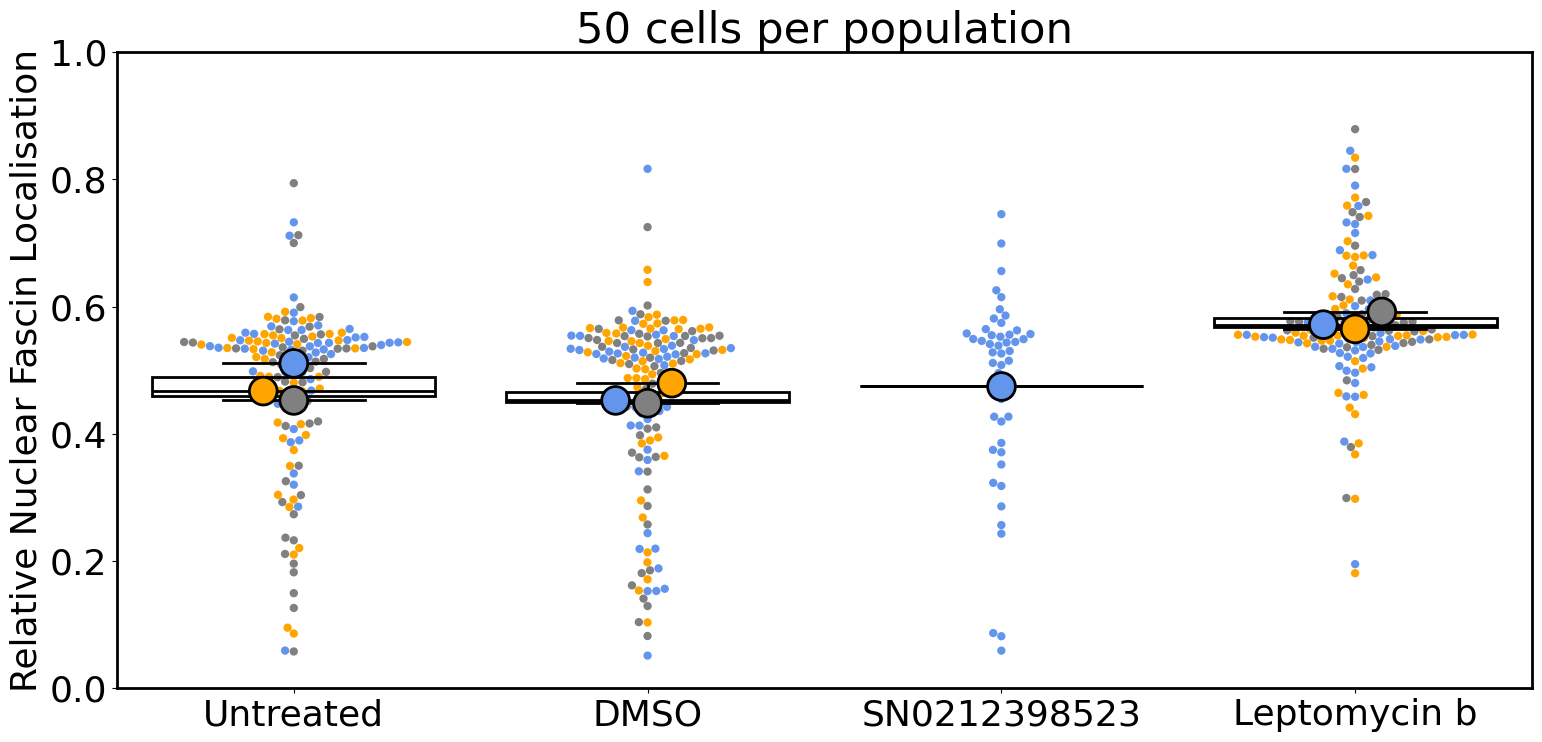

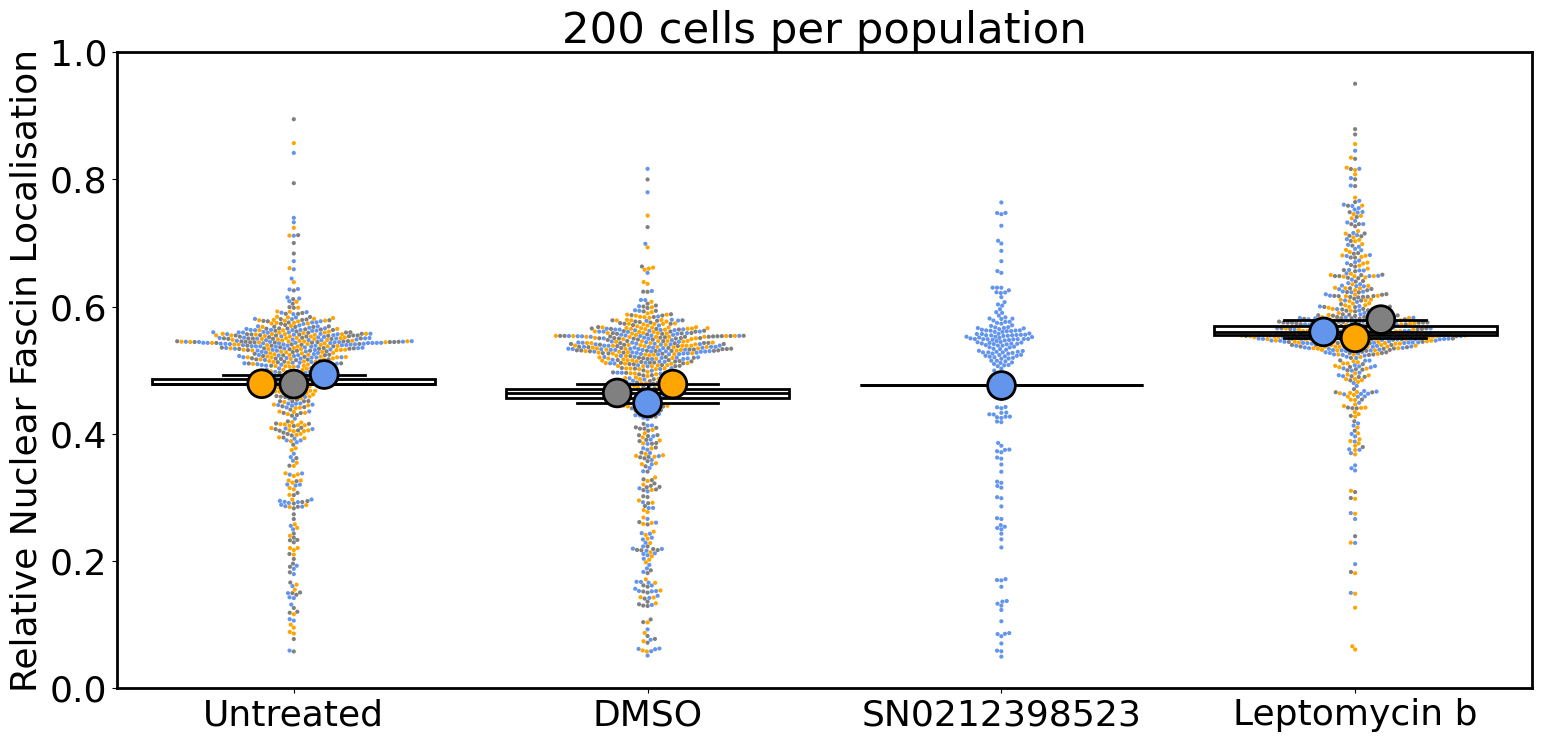

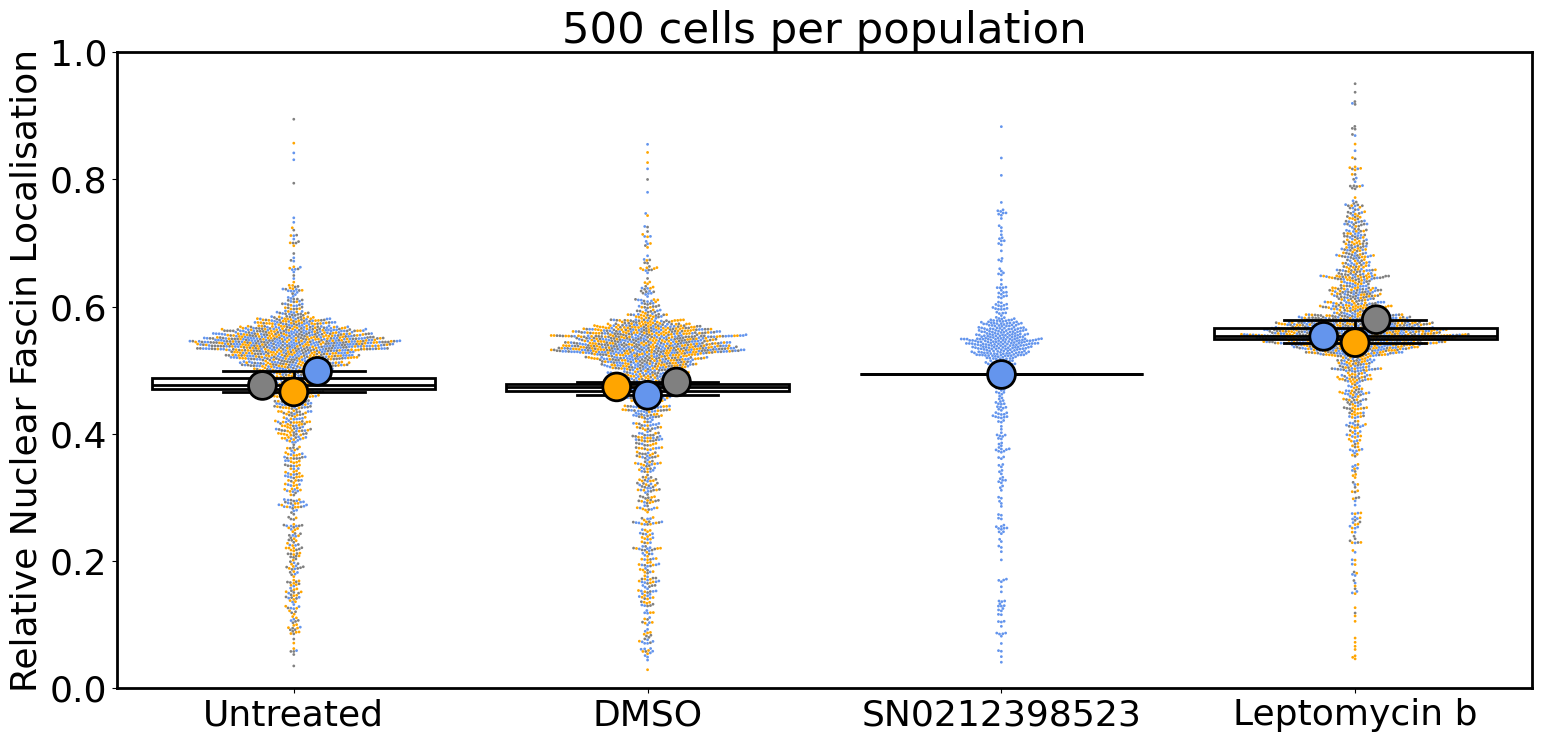

In [12]:
selected_treatments = ['Untreated', 'DMSO', 'SN0212398523', 'Leptomycin b']
point_size = {50: 6, 200: 3, 500: 2}
for s in [50, 200, 500]:
    generate_superplot(selected_treatments, selected_treatments,
                       prepare_data(nuc_data, cyto_data, image_data, None, treatments, treatments_to_compounds,
                                    compounds, ['J05', 'I19', 'G15', 'O02', 'B02', 'N12', 'L08', 'L18', 'H13', 'E22'],
                                    ['Fascin']), treatment_col, 'Well', variable_of_interest, y_label, sample_size=s,
                       point_size=point_size[s])